Setup

In [1]:
from pathlib import Path
import sys

import torch
import torch.nn as nn

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataloader import create_dataloaders
from src.models.resnet50 import create_resnet50
from src.training.trainer import train_model
from src.utils.seed import set_seed

set_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


Data

In [2]:
loaders = create_dataloaders(
    dataset_root=PROJECT_ROOT / "data/raw/garbage-dataset",
    manifest_dir=PROJECT_ROOT / "data/manifests",
    batch_size=32,
    num_workers=0,
)

train_loader = loaders["train_loader"]
val_loader = loaders["val_loader"]

class_to_idx = loaders["class_to_idx"]

print("Training images:", len(loaders["train_dataset"]))
print("Validation images:", len(loaders["val_dataset"]))
print(class_to_idx)

Training images: 13833
Validation images: 2964
{'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}


Model

In [3]:
model = create_resnet50(
    num_classes=10,
    pretrained=True,
    freeze_backbone=True,
)

model = model.to(device)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

Trainable parameters: 20,490


Loss and optimizer

In [4]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters(),
    ),
    lr=0.001,
    weight_decay=0.0001,
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


Run the actual training

In [5]:
checkpoint_path = (
    PROJECT_ROOT
    / "results"
    / "checkpoints"
    / "resnet50_frozen_best.pth"
)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    checkpoint_path=checkpoint_path,
)


Epoch 1/10


Training:   0%|          | 0/433 [00:00<?, ?it/s]

Validation:   0%|          | 0/93 [00:00<?, ?it/s]

Train Loss: 0.5721 | Train Acc: 0.8454
Val Loss:   0.2952 | Val Acc:   0.9217
Time: 160.8s
Best model saved (val_loss=0.2952)

Epoch 2/10


Training:   0%|          | 0/433 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/93 [00:00<?, ?it/s]

Train Loss: 0.1391 | Train Acc: 0.9555
Val Loss:   0.1697 | Val Acc:   0.9497
Time: 132.3s
Best model saved (val_loss=0.1697)

Epoch 10/10


Training:   0%|          | 0/433 [00:00<?, ?it/s]

Validation:   0%|          | 0/93 [00:00<?, ?it/s]

Train Loss: 0.1320 | Train Acc: 0.9579
Val Loss:   0.1771 | Val Acc:   0.9450
Time: 133.1s


Plot the learning curves

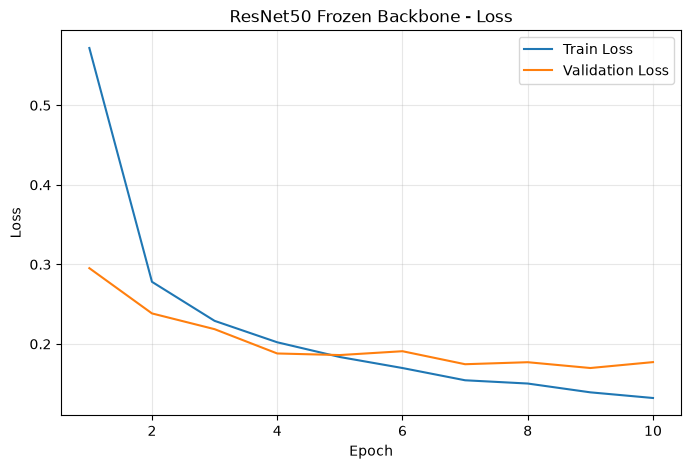

In [6]:
import matplotlib.pyplot as plt

epochs = range(
    1,
    len(history["train_loss"]) + 1,
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss",
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "ResNet50 Frozen Backbone - Loss"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

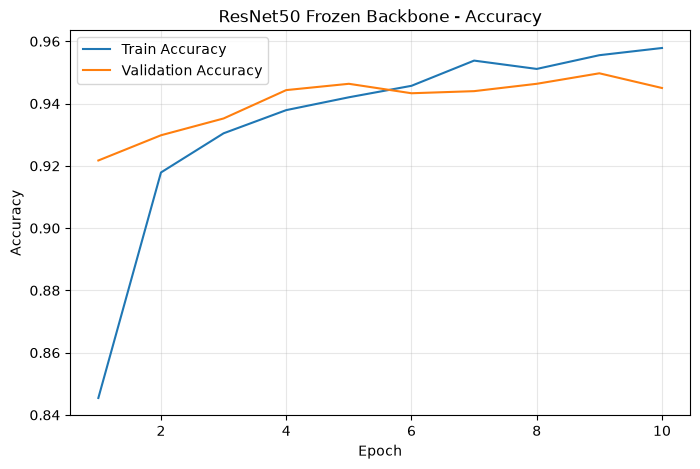

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    label="Train Accuracy",
)

plt.plot(
    epochs,
    history["val_accuracy"],
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "ResNet50 Frozen Backbone - Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

Load the BEST model, not the final epoch

In [8]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "Best epoch:",
    checkpoint["epoch"],
)

print(
    "Best validation loss:",
    checkpoint["val_loss"],
)

print(
    "Validation accuracy at best epoch:",
    checkpoint["val_accuracy"],
)

Best epoch: 9
Best validation loss: 0.16968892805539726
Validation accuracy at best epoch: 0.9497300944669366


Calculate validation metrics

In [9]:
from src.evaluation.metrics import (
    collect_predictions,
    calculate_classification_metrics,
)

y_true, y_pred, y_prob = collect_predictions(
    model=model,
    dataloader=val_loader,
    device=device,
)

class_names = [
    class_name
    for class_name, index
    in sorted(
        class_to_idx.items(),
        key=lambda item: item[1],
    )
]

metrics, report, matrix = (
    calculate_classification_metrics(
        y_true=y_true,
        y_pred=y_pred,
        class_names=class_names,
    )
)

for metric_name, value in metrics.items():
    print(
        f"{metric_name}: {value:.4f}"
    )

accuracy: 0.9497
macro_precision: 0.9372
macro_recall: 0.9432
macro_f1: 0.9394
weighted_f1: 0.9496


In [10]:
import pandas as pd

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
battery,0.931973,0.964789,0.948097,142.00000
biological,0.961039,0.986667,0.973684,150.00000
cardboard,0.955390,0.937956,0.946593,274.00000
clothes,0.992434,0.984981,0.988693,799.00000
glass,0.925847,0.952070,0.938776,459.00000
metal,0.843023,0.947712,0.892308,153.00000
paper,0.951220,0.928571,0.939759,252.00000
plastic,0.961538,0.841751,0.897666,297.00000
shoes,0.941935,0.986486,0.963696,296.00000
trash,0.907801,0.901408,0.904594,142.00000


In [11]:
report_path = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resnet50_frozen_validation_report.csv"
)

report_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

report_df.to_csv(report_path)

print("Saved:", report_path)

Saved: c:\Users\USER\Desktop\SLIIT\DL\Assignment\waste-classification\results\tables\resnet50_frozen_validation_report.csv
